# Ejemplo: Ejecutar regresión lineal simple


## Introducción

Mientras aprendes, la regresión lineal simple es una forma de modelar la relación entre dos variables. Al evaluar la dirección y la magnitud de una relación, los profesionales de datos pueden descubrir patrones y transformar grandes cantidades de datos en conocimientos valiosos. Esto les permite hacer mejores predicciones y decisiones. 

En este laboratorio, eres parte de un equipo de análisis que proporciona ideas sobre las prácticas de ventas y marketing de tu empresa. Se te ha asignado un proyecto que se centra en el uso del marketing de influencers. Para esta tarea, explorarás la relación entre tu presupuesto de promoción en radio y tus ventas. 

El conjunto de datos proporcionado incluye información sobre campañas de marketing en televisión, radio y redes sociales, así como cuánto ingreso en ventas se generó a partir de estas campañas. Basándose en esta información, los líderes de la empresa tomarán decisiones sobre dónde enfocar futuros recursos de marketing. Por lo tanto, es fundamental proporcionarles una comprensión clara de la relación entre los tipos de campañas de marketing y los ingresos generados como resultado de esta inversión.


# Repaso Teórico: Regresión Lineal Simple

La **regresión lineal simple** es una técnica estadística que estima la relación lineal entre una variable independiente $X$ y una variable dependiente continua $Y$.

## Ecuación de la recta de regresión

$$
Y = \beta_0 + \beta_1 X
$$

- $\beta_0$: Intercepto
- $\beta_1$: Pendiente

El objetivo es encontrar la recta que **mejor se ajusta** a los datos, minimizando el error.

## Mínimos Cuadrados Ordinarios (MCO)

El método de **Mínimos Cuadrados Ordinarios (MCO)** busca minimizar la suma de los residuos al cuadrado:

$$
SSR = \sum (Y_i - \hat{Y}_i)^2
$$

Donde:
- $Y_i$: Valor observado
- $\hat{Y}_i$: Valor predicho por el modelo

### Estimación de los coeficientes

Pendiente:
$$
\hat{\beta}_1 = 
\frac{
\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})
}{
\sum_{i=1}^{n} (X_i - \bar{X})^2
}
$$

Intercepto:
$$
\hat{\beta}_0 = \bar{Y} - \hat{\beta}_1 \bar{X}
$$

## Correlación

El **coeficiente de correlación de Pearson ($r$)** mide la fuerza y dirección de la relación lineal entre $X$ e $Y$:

$$
r = \frac{\text{cov}(X,Y)}{(SD_X)(SD_Y)}
$$

- $r > 0$: Correlación positiva
- $r < 0$: Correlación negativa
- $r = 0$: No hay correlación lineal

## Supuestos de la regresión lineal simple

1. **Linealidad**: La relación entre $X$ e $Y$ es lineal.
2. **Normalidad**: Los residuos se distribuyen normalmente.
3. **Independencia**: Las observaciones son independientes.
4. **Homocedasticidad**: La varianza de los residuos es constante.

## Ejemplo

Supón los siguientes datos de estudiantes:

| Horas (X) | Nota (Y) |
|-----------|----------|
| 2         | 75       |
| 4         | 65       |
| 5         | 80       |
| 6         | 95       |
| 8         | 85       |

- $\bar{X} = 5$
- $\bar{Y} = 80$
- $SD_X = 2$
- $SD_Y = 10$
- $r = 0.6$

Pendiente:
$$
m = r \frac{SD_Y}{SD_X} = 0.6 \cdot \frac{10}{2} = 3
$$

Intercepto:
$$
b = \bar{Y} - m\bar{X} = 80 - 3 \cdot 5 = 65
$$

**Ecuación final:**
$$
y = 3x + 65
$$

## Paso 1: Importaciones


### En esta sección, primero importa las bibliotecas y módulos relevantes de Python.


In [1]:
# Import relevant Python libraries and modules

### YOUR CODE HERE ###

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.api as sm

### Ahora carga el conjunto de datos en un DataFrame.

El conjunto de datos proporcionado es un archivo csv (llamado `marketing_sales_data.csv`) que contiene información sobre marketing promocional realizado en colaboración con influencers, junto con las ventas correspondientes. Este es un conjunto de datos ficticio que fue creado con fines educativos y modificado para este laboratorio. Suponga que las variables numéricas en los datos están expresadas en millones de dólares.


In [3]:
# Load the dataset into a DataFrame and save in a variable

### YOUR CODE HERE ###

data = pd.read_csv("marketing_sales_data.csv")

<details>
  <summary><h4><strong>PISTA 1</strong></h4></summary>

Puedes consultar lo que aprendiste sobre cargar datos en Python.

</details>


<details>
  <summary><h4><strong>PISTA 2</strong></h4></summary>

Hay una función en la biblioteca `pandas` que permite leer datos de un archivo csv y cargar los datos en un DataFrame.
 

</details>


<details>
  <summary><h4><strong>PISTA 3</strong></h4></summary>

Utilice la función `read_csv()` de la biblioteca `pandas`. 

</details>


## Paso 2. Exploración de datos


### Para tener una idea de lo que incluyen los datos, mostrar las primeras 10 filas de los datos.


In [4]:
# Display the first 10 rows of the data

### YOUR CODE HERE ###

data.head(10)

,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328
5,High,25.561910,5.459718,Micro,261.966812
6,High,37.263819,6.886535,Nano,349.861575
7,Low,13.187256,2.766352,Macro,140.415286
8,High,29.520170,2.333157,Nano,264.592233
9,Low,3.773287,0.135074,Nano,55.674214


<details>
  <summary><h4><strong>PISTA 1</strong></h4></summary>

Puede que te sea útil volver a consultar lo que aprendiste sobre explorar conjuntos de datos en Python.

</details>


<details>
  <summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función en la biblioteca `pandas` que permite obtener un número específico de filas desde la parte superior de un DataFrame.
 

</details>


<details>
  <summary><h4><strong>PISTA 3</strong></h4></summary>

Utiliza la función `head()` de la biblioteca `pandas`. 

</details>


#### **Pregunta 1**: ¿Qué observas acerca de las diferentes variables incluidas en los datos?

- Los datos incluyen la siguiente información:
    - Presupuesto de promoción en televisión (expresado como "Bajo", "Medio" o "Alto")
    - Presupuesto de promoción en radio
    - Presupuesto de promoción en redes sociales
    - Tipo de influencer con el que se realiza la colaboración en la promoción (expresado como "Mega", "Macro" o "Micro", o "Nano")
        - Nota: Los mega-influencers tienen más de 1 millón de seguidores, los macro-influencers tienen de 100,000 a 1 millón de seguidores, los micro-influencers tienen de 10,000 a 100,000 seguidores, y los nano-influencers tienen menos de 10,000 seguidores.
    - Ventas generadas por la promoción


### Para tener una idea de qué tan grande es la data, identifica el número de filas y el número de columnas en los datos.


In [5]:
# Display number of rows, number of columns

### YOUR CODE HERE ###

data.shape

(572, 5)

<details>
  <summary><h4><strong>PISTA 2</strong></h4></summary>

Hay una propiedad que cada DataFrame en `pandas` tiene; te da acceso al número de filas y al número de columnas como una tupla.

</details>


<details>
  <summary><h4><strong>PISTA 1</strong></h4></summary>

Puede que te sea útil volver a consultar lo que aprendiste sobre explorar conjuntos de datos en Python.

</details>


<details>
  <summary><h4><strong>PISTA 3</strong></h4></summary>

Utiliza la propiedad `shape`.

</details>


#### **Pregunta 2**: ¿Qué observas acerca del número de filas y número de columnas en los datos?

- Hay 572 filas y 5 columnas en los datos. Una forma de interpretar esto es que 572 empresas están representadas en los datos, junto con 5 aspectos sobre cada empresa que revelan cómo promocionan sus productos/servicios y las ventas acumuladas por su promoción.


Ahora, verifica si hay valores faltantes en las filas de los datos. Esto es importante porque los valores faltantes no son tan significativos al modelar la relación entre dos variables. Para hacerlo, comienza obteniendo booleanos que indiquen si cada valor en los datos falta. Luego, verifica tanto las columnas como las filas en busca de valores faltantes.


In [6]:
# Step 1. Start with .isna() to get booleans indicating whether each value in the data is missing

### YOUR CODE HERE ###

data.isna()

,TV,Radio,Social Media,Influencer,Sales
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
567,False,False,False,False,False
568,False,False,False,False,False
569,False,False,False,False,False
570,False,False,False,False,False


Si deseas leer más sobre la función `isna()`, no dudes en consultar su documentación, disponible en la sección de referencias de este laboratorio.


In [7]:
# Step 1. Start with .isna() to get booleans indicating whether each value in the data is missing
# Step 2. Use .any(axis=1) to get booleans indicating whether there are any missing values along the columns in each row

### YOUR CODE HERE ###

data.isna().any(axis=1)

0      False
1      False
2      False
3      False
4      False
       ...  
567    False
568    False
569    False
570    False
571    False
Length: 572, dtype: bool

Si desea leer más sobre la función `any()`, no dude en consultar su documentación, disponible en la sección de referencias de este laboratorio.


In [8]:
# Step 1. Start with .isna() to get booleans indicating whether each value in the data is missing
# Step 2. Use .any(axis=1) to get booleans indicating whether there are any missing values along the columns in each row
# Step 3. Use .sum() to get the number of rows that contain missing values

### YOUR CODE HERE ###

data.isna().any(axis=1).sum()

np.int64(3)

Si desea leer más sobre la función `sum()`, no dude en consultar su documentación, disponible en la sección de referencias de este laboratorio.


#### **Pregunta 3**: ¿Qué observas sobre el número de filas que contienen valores faltantes?

- Hay 3 filas que contienen valores faltantes, lo cual no es tanto, considerando el número total de filas. Sería apropiado eliminar estas filas que contienen valores faltantes para proceder con la preparación de los datos para el modelado.


### Elimina las filas que contienen valores faltantes.
Este es un paso importante en la limpieza de datos, ya que hace que los datos sean más útiles para el análisis y la regresión que realizarás a continuación.


In [8]:
# Step 1. Use .dropna(axis=0) to indicate that you want rows which contain missing values to be dropped
# Step 2. To update the DataFrame, reassign it to the result

### YOUR CODE HERE ###

data = data.dropna(axis=0)

In [9]:
# Check to make sure that the data does not contain any rows with missing values now

# Step 1. Start with .isna() to get booleans indicating whether each value in the data is missing
# Step 2. Use .any(axis=1) to get booleans indicating whether there are any missing values along the columns in each row
# Step 3. Use .sum() to get the number of rows that contain missing values

### YOUR CODE HERE ###

data.isna().any(axis=1).sum()

np.int64(3)

### Verificar las suposiciones del modelo.
Te gustaría explorar la relación entre el presupuesto de promoción en radio y las ventas. Podrías modelar la relación usando regresión lineal. Para hacer esto, quieres verificar si las suposiciones del modelo para regresión lineal pueden hacerse en este contexto. Algunas de las suposiciones pueden abordarse antes de construir el modelo --- abordarás esas en esta sección. Después de que el modelo esté construido, puedes terminar de verificar las suposiciones.


### Comienza creando un gráfico de relaciones por pares en los datos.
Esto te ayudará a visualizar las relaciones entre variables en los datos y a verificar las suposiciones del modelo.


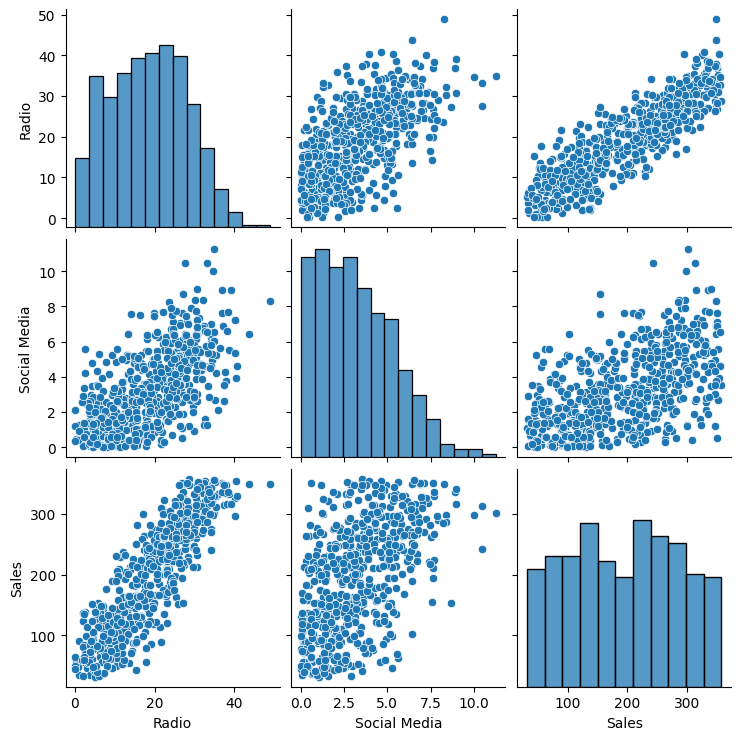

In [10]:
# Create plot of pairwise relationships

### YOUR CODE HERE ###

sns.pairplot(data)

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede que le sea útil volver a la sección del video sobre cómo crear un gráfico que muestre las 
  relaciones entre pares de variables.

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función en la biblioteca `seaborn` que puedes llamar para crear un gráfico que muestra las 
  relaciones entre pares de variables.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Puedes llamar a la función `pairplot()` de la biblioteca `seaborn`.

</details>


#### **Pregunta 4**: ¿Se cumple la suposición de linealidad?

- En el diagrama de dispersión de `Ventas` sobre `Radio`, los puntos parecen agruparse alrededor de una línea que indica una asociación positiva entre las dos variables. Dado que los puntos se agrupan alrededor de una línea, parece que se cumple la suposición de linealidad.


<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede que le sea útil consultar la sección de video sobre cómo verificar las suposiciones del modelo para regresión lineal.

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Use el diagrama de dispersión de `Sales` sobre `Radio` que se encuentra en el gráfico anterior de relaciones por pares.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Verifique el diagrama de dispersión de `Ventas` sobre `Radio` que se encuentra en el gráfico anterior de relaciones por pares. Si los puntos de datos se agrupan alrededor de una línea, eso indicaría que se cumple la suposición de linealidad. Alternativamente, si los puntos de datos parecen una nube aleatoria o una curva, entonces un modelo lineal puede no ajustarse bien a los datos.  

</details>


## Paso 3. Construcción del Modelo


### Comience seleccionando solo las columnas que son necesarias para el modelo que construirá a partir de los datos.


In [11]:
# Select relevant columns
# Save resulting DataFrame in a separate variable to prepare for regression

### YOUR CODE HERE ###

ols_data = data[["Radio", "Sales"]]

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede que le sea útil consultar la sección de video sobre cómo seleccionar varias columnas de un DataFrame.

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Use dos pares de corchetes alrededor de los nombres de las columnas que deben ser seleccionadas.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Asegúrate de que los nombres de las columnas estén escritos exactamente como en los datos.

</details>


### Mostrar las primeras 10 filas del nuevo DataFrame para asegurar que es correcto.


In [12]:
# Display first 10 rows of the new DataFrame

### YOUR CODE HERE ###

ols_data.head(10)

,Radio,Sales
0,1.218354,90.054222
1,14.949791,222.741668
2,10.377258,102.774790
3,26.469274,328.239378
4,36.876302,351.807328
5,25.561910,261.966812
6,37.263819,349.861575
7,13.187256,140.415286
8,29.520170,264.592233
9,3.773287,55.674214


<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede que le sea útil consultar la sección de video sobre cómo mostrar el contenido de un DataFrame.

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función en la biblioteca `pandas` que permite mostrar las primeras n filas de un DataFrame, donde n es un número de tu elección.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Llama a la función `head()` de la biblioteca `pandas` y pasa el número de filas desde la parte superior que deseas mostrar. 

</details>


### Escribe la fórmula de regresión lineal para modelar la relación entre las dos variables de interés.


In [13]:
# Write the linear regression formula
# Save it in a variable

### YOUR CODE HERE ###
ols_formula = "Sales ~ Radio"


<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede ser útil consultar la sección de video donde se discute la construcción del modelo para regresión lineal.

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Guarda la fórmula como cadena.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Usa una tilde para separar la variable y de la variable x para que la computadora entienda cuál es cuál. Asegúrate de que la ortografía de cada variable coincida exactamente con la columna correspondiente de los datos.

</details>


### Implementar el método de Mínimos Cuadrados Ordinarios (MCO) para regresión lineal.


In [14]:
# Implement OLS

### YOUR CODE HERE ###

OLS = ols(formula = ols_formula, data = ols_data)

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede ser útil consultar la sección de video donde se discute la construcción del modelo para regresión lineal.  

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función de la biblioteca `statsmodels` que se puede llamar para implementar OLS.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Puedes llamar a la función `ols()` de la biblioteca `statsmodels`.

</details>


### Crear un modelo de regresión lineal para los datos y ajustar el modelo a los datos.


In [15]:
# Fit the model to the data
# Save the fitted model in a variable

### YOUR CODE HERE ###

model = OLS.fit()

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede que le sea útil consultar la sección de video donde se discute la construcción del modelo para regresión lineal.  

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función de la biblioteca `statsmodels` que se puede llamar para ajustar el modelo.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Puedes llamar a la función `fit()` de la biblioteca `statsmodels`.

</details>


## Paso 4. Resultados y Evaluación


### Obtener un resumen de los resultados del modelo.


In [20]:
# Get summary of results

### YOUR CODE HERE ###

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1781.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          2.96e-177
Time:                        16:37:55   Log-Likelihood:                -2971.5
No. Observations:                 570   AIC:                             5947.
Df Residuals:                     568   BIC:                             5956.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.4488      4.061     10.206      0.0

In [21]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1781.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          2.96e-177
Time:                        16:38:24   Log-Likelihood:                -2971.5
No. Observations:                 570   AIC:                             5947.
Df Residuals:                     568   BIC:                             5956.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.4488      4.061     10.206      0.000      33.472      49.426
Radio          8.1799      0.194     42.206      0.000       7.799       8.561
==============================================================================
Omnibus:                        2.272   Durbin-Watson:                   1.881
Prob(Omnibus):                  0.321   Jarque-Bera (JB):                2.236
Skew:                          -0.105   Prob(JB):                        0.327
Kurtosis:                       2.776   Cond. No.                         45.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede que le sea útil consultar la sección de video donde se discuten los resultados del modelo.  

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función de la biblioteca `statsmodels` que se puede llamar para obtener el resumen de resultados de un modelo.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Puedes llamar a la función `summary()` de la biblioteca `statsmodels`.

</details>


### Analizar la tabla inferior del resumen de resultados.

Basándose en esa tabla, identifique los coeficientes que el modelo determinó que generarían la línea de mejor ajuste, los coeficientes aquí siendo la intersección en y y la pendiente.


#### **Pregunta 5**: ¿Cuál es la intersección en y? 

- La intersección en y es 41.5326.


#### **Pregunta 6**: ¿Cuál es la pendiente? 

- La pendiente es 8.1733.


#### **Pregunta 7**: ¿Cuál es la ecuación lineal que escribirías para expresar la relación entre ventas y presupuesto de promoción en radio en la forma de y = pendiente * x + intersección en y?

- ventas = 8.1733 * presupuesto de promoción en radio + 41.5326


#### **Pregunta 8**: ¿Qué crees que significa la pendiente en este contexto?

- Una interpretación: Si una empresa tiene un presupuesto de 1 millón de dólares más para promocionar sus productos/servicios en la radio, las ventas de la empresa aumentarían en 8.1733 millones de dólares en promedio.
- Otra interpretación: Las empresas con 1 millón de dólares más en su presupuesto de promoción en la radio acumulan 8.1733 millones de dólares más en ventas en promedio.


### Terminar de verificar las suposiciones del modelo.

Ahora que has construido el modelo de regresión lineal y lo has ajustado a los datos, puedes terminar de verificar las suposiciones del modelo. Esto ayudará a confirmar tus hallazgos.


### Traza los datos de MCO con la línea de regresión de mejor ajuste.


<Axes: xlabel='Radio', ylabel='Sales'>

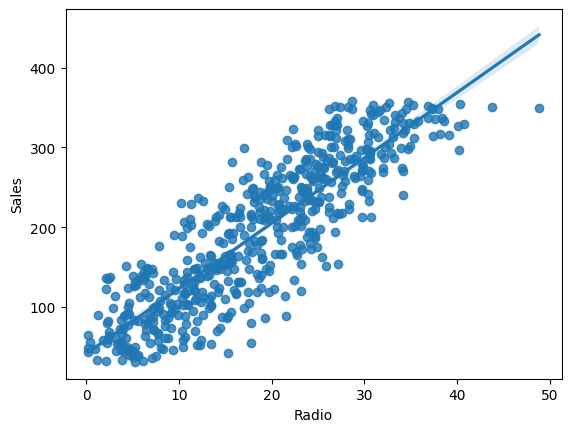

In [22]:
# Plot the OLS data with the best fit regression line

### YOUR CODE HERE ###

sns.regplot(x = "Radio", y = "Sales", data = ols_data)

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede ser útil consultar la sección de video donde se discute cómo graficar los datos con la línea de regresión de mejor ajuste.

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función de la biblioteca `seaborn` que puede ser útil aquí.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Puedes llamar a la función `regplot()` de la biblioteca `seaborn`.

</details>


#### **Pregunta 9**: ¿Qué observas en el gráfico de regresión anterior?

- El gráfico de regresión anterior ilustra una relación aproximadamente lineal entre las dos variables junto con la línea de mejor ajuste. Esto confirma la suposición de linealidad.


### Verifique la suposición de normalidad.

Para comenzar, obtenga los residuos del modelo.


## Repaso: Supuestos de Normalidad, Independencia y Varianza Constante

### Normalidad de los residuos

El supuesto de **normalidad** indica que los residuos (errores) del modelo deben distribuirse aproximadamente de forma normal (campana de Gauss). Esto es importante para la validez de los intervalos de confianza y pruebas de hipótesis.

- **¿Cómo se verifica?**  
  - Gráfica Q-Q (quantile-quantile): los puntos deben alinearse con la diagonal.
  - Histograma de residuos: debe mostrar forma de campana.

- **¿Qué hacer si no se cumple?**  
  - Probar transformaciones de variables (log, raíz cuadrada, etc.).
  - Considerar modelos robustos o no paramétricos.


In [23]:
# Get the residuals from the model

### YOUR CODE HERE ###

residuals = model.resid

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede que le sea útil consultar la sección de video donde se discute cómo acceder a los residuos.  

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay un atributo de la biblioteca `statsmodels` que se puede llamar para obtener los residuos de un modelo ajustado.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Puedes llamar al atributo `resid` de la biblioteca `statsmodels`.

</details>


Visualice la distribución de los residuos.


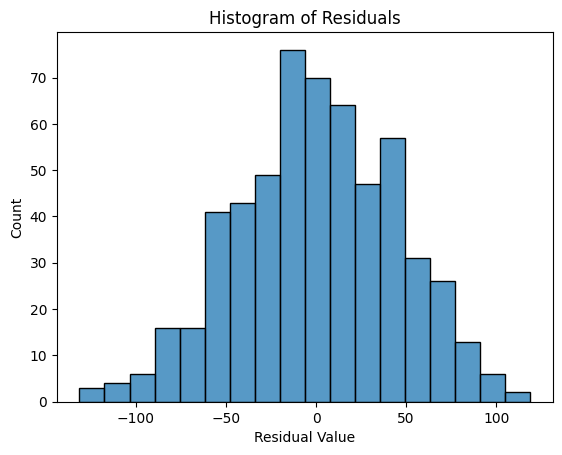

In [24]:
# Visualize the distribution of the residuals

### YOUR CODE HERE ###

fig = sns.histplot(residuals)
fig.set_xlabel("Residual Value")
fig.set_title("Histogram of Residuals")
plt.show()

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede que le sea útil volver a la sección de video donde se discute la visualización de residuos.  

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función de la biblioteca `seaborn` que se puede llamar para crear un histograma.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Puedes llamar a la función `histplot()` de la biblioteca `seaborn`.

</details>


#### **Pregunta 10**: Basándose en la visualización anterior, ¿qué observa acerca de la distribución de los residuos?

- Basándose en la visualización anterior, la distribución de los residuos es aproximadamente normal. Esto indica que la suposición de normalidad probablemente se cumple.


### Crear un gráfico Q-Q para confirmar la suposición de normalidad.


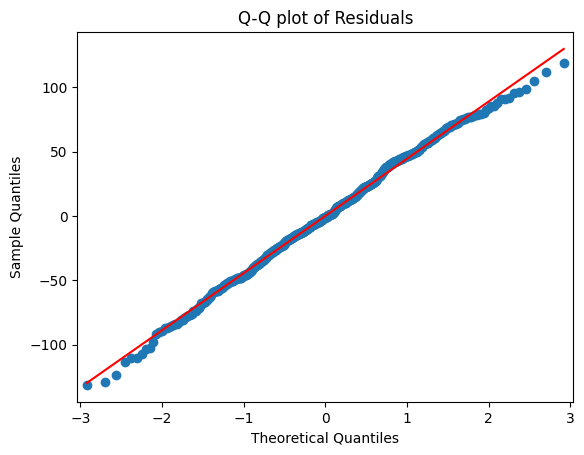

In [25]:
# Create a Q-Q plot 

### YOUR CODE HERE ###

sm.qqplot(residuals, line='s')
plt.title("Q-Q plot of Residuals")
plt.show()

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede que le sea útil consultar la sección de video donde se discute cómo crear un gráfico Q-Q.  

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función de la biblioteca `statsmodels` que se puede llamar para crear un gráfico Q-Q.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Puedes llamar a la función `qqplot()` de la biblioteca `statsmodels`.

</details>


#### **Pregunta 11**: ¿Se cumple la suposición de normalidad?

- En el gráfico Q-Q anterior, los puntos siguen de cerca una línea diagonal recta que apunta hacia arriba. Esto confirma que se cumple la suposición de normalidad.


### Verifique las suposiciones de observación independiente y homocedasticidad.

Comience obteniendo los valores ajustados del modelo.


### Independencia de las observaciones

El supuesto de **independencia** significa que cada observación es ajena a las demás; es decir, el valor de una no afecta a otra.

- **¿Cómo se verifica?**  
  - Analizando el proceso de recolección de datos.
  - Gráfico de residuos vs. valores ajustados: debe verse como una nube aleatoria.

- **¿Qué hacer si no se cumple?**  
  - Revisar el diseño del estudio.
  - Considerar modelos para datos correlacionados (series temporales, datos agrupados).

---

### Homocedasticidad (Varianza constante)

La **homocedasticidad** o “varianza constante” significa que la dispersión de los residuos es similar a lo largo de todos los valores predichos. Si la varianza cambia, se llama **heterocedasticidad**.

- **¿Cómo se verifica?**  
  - Gráfico de residuos vs. valores ajustados: la dispersión debe ser uniforme, sin formar patrones (como conos o abanicos).

- **¿Qué hacer si no se cumple?**  
  - Probar transformaciones de variables.
  - Usar modelos que corrijan la heterocedasticidad (regresión robusta).


In [27]:
# Get fitted values

### YOUR CODE HERE ###

fitted_values = model.predict(ols_data["Radio"])

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede ser útil consultar la sección de video donde se discute cómo calcular los valores ajustados.  

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función de la biblioteca `statsmodels` que se puede llamar para calcular los valores ajustados del modelo.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Puedes llamar a la función `predict()` de la biblioteca `statsmodels`. Asegúrate de pasar la columna de `ols_data` que corresponde a la variable x.

</details>


Crear un diagrama de dispersión de los residuos contra los valores ajustados.


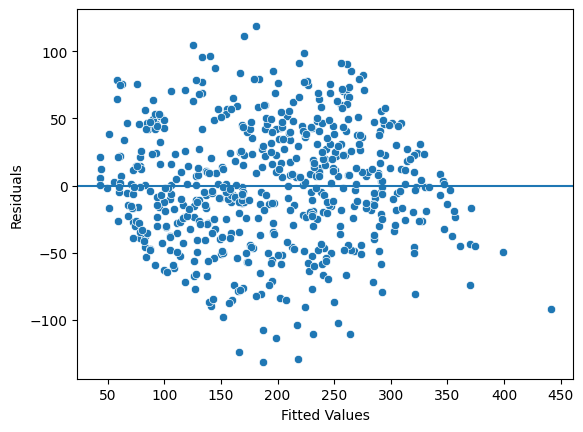

In [28]:
# Create a scatterplot of residuals against fitted values

### YOUR CODE HERE ###

fig = sns.scatterplot(x=fitted_values, y=residuals)
fig.axhline(0)
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")
plt.show()

<details>
<summary><h4><strong>PISTA 1</strong></h4></summary>

  Puede ser útil consultar la sección de video donde se discute la visualización de residuos contra valores ajustados.

</details>


<details>
<summary><h4><strong>PISTA 2</strong></h4></summary>

  Hay una función de la biblioteca `seaborn` que se puede llamar para crear un diagrama de dispersión.

</details>


<details>
<summary><h4><strong>PISTA 3</strong></h4></summary>

  Puedes llamar a la función `scatterplot()` de la biblioteca `seaborn`.

</details>


#### **Pregunta 12**: ¿Se cumplen las suposiciones de observación independiente y homocedasticidad?

- En el diagrama de dispersión anterior, los puntos de datos tienen un parecido a una nube y no siguen un patrón explícito. Entonces, parece que la suposición de observación independiente no ha sido violada. Dado que los residuos parecen estar distribuidos aleatoriamente, la suposición de homocedasticidad parece estar cumplida.


## Conclusión

**¿Cuáles son los puntos clave de este laboratorio?**
- Las visualizaciones de datos y el análisis exploratorio de datos se pueden usar para verificar si la regresión lineal es un enfoque adecuado para modelar la relación entre dos variables.
- Los resultados de un modelo de regresión lineal se pueden usar para expresar la relación entre dos variables.

**¿Qué resultados se pueden presentar de este laboratorio?**

En el modelo de regresión lineal simple, la intersección y es 41.5326 y la pendiente es 8.1733. 
    Una interpretación: Si una empresa tiene un presupuesto de 1 millón de dólares más para promover sus productos/servicios en la radio, las ventas de la empresa aumentarían en 8.1733 millones de dólares en promedio.
    Otra interpretación: Las empresas con 1 millón de dólares más en su presupuesto de promoción en la radio acumulan 8.1733 millones de dólares más en ventas en promedio.

Los resultados son estadísticamente significativos con un valor p de 0.000, que es un valor muy pequeño (y menor que el nivel de significancia común de 0.05). Esto indica que hay una probabilidad muy baja de observar datos tan extremos o más extremos que este conjunto de datos cuando la hipótesis nula es verdadera. En este contexto, la hipótesis nula es que no hay relación entre el presupuesto de promoción en la radio y las ventas, es decir, la pendiente es cero, y la hipótesis alternativa es que hay una relación entre el presupuesto de promoción en la radio y las ventas, es decir, la pendiente no es cero. Entonces, podrías rechazar la hipótesis nula y afirmar que hay una relación entre el presupuesto de promoción en la radio y las ventas para las empresas en estos datos.

La pendiente de la línea de mejor ajuste que resultó del modelo de regresión es aproximada y está sujeta a incertidumbre (no es el valor exacto). El intervalo de confianza del 95% para la pendiente va desde 7.791 hasta 8.555. Esto indica que hay un 95% de probabilidad de que el intervalo [7.791, 8.555] contenga el valor verdadero de la pendiente.

**¿Cómo enmarcarías tus hallazgos para las partes interesadas externas?**

Basándose en el conjunto de datos actual y en el análisis de regresión realizado aquí, hay una relación notable entre el presupuesto de promoción en la radio y las ventas para las empresas en estos datos, con un valor p de 0.000 y un error estándar de 0.194. Para las empresas representadas por estos datos, un aumento de 1 millón de dólares en el presupuesto de promoción en la radio podría estar asociado con un aumento de 8.1733 millones de dólares en ventas. Valdría la pena seguir promoviendo productos/servicios en la radio. Además, se recomienda considerar un análisis adicional de la relación entre las dos variables (presupuesto de promoción en la radio y ventas) en diferentes contextos. Por ejemplo, sería útil recopilar más datos para entender si esta relación es diferente en ciertos sectores o al promover ciertos tipos de productos/servicios.


**Referencias**

Pandas.DataFrame.Any — Documentación de Pandas 1.4.3. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.any.html.

Pandas.DataFrame.Isna — Documentación de Pandas 1.4.3. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html.

Pandas.Series.Sum — Documentación de Pandas 1.4.3. https://pandas.pydata.org/docs/reference/api/pandas.Series.sum.html.

Saragih, H.S. *Datos ficticios de marketing y ventas*. https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data.


**¡Felicidades!** Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa con tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo ha sido registrado.
